# Análisis exploratorio — Gimnasio FitLife

Notebook de experimentación con el análisis exploratorio de comportamiento de clientes del gimnasio en relación a darse o no de baja

In [ ]:
import matplotlib

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pathlib import Path
from datetime import date

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
SEED = 42
TODAY = date.today()


## 1 · Carga y construcción del dataset maestro

In [2]:
def load(name):
    return pd.read_csv(DATA_DIR / f'{name}.csv', encoding='utf-8-sig', low_memory=False)

contactos     = load('contactos').rename(columns={'id': 'cliente_id'})
crm           = load('crm_leads')
ventas        = load('ventas_servicios')
suscripciones = load('suscripciones')
facturacion   = load('facturacion')
marketing     = load('marketing_automation')
encuestas     = load('encuestas_satisfaccion')
eventos       = load('eventos_participacion')
helpdesk      = load('helpdesk_tickets')
actividad     = load('actividad_deportiva')
engagement    = load('engagement').rename(columns={'participacion_retos': 'participacion_retos_eng'})
centros       = load('centros_deportivos')

print(f'Clientes totales: {len(contactos)}')
print(f'Target:\n{contactos["estado"].value_counts()}')


Clientes totales: 500
Target:
estado
Activo    398
Baja      102
Name: count, dtype: int64


In [3]:
df = contactos.copy()

for t in [
    crm, 
    ventas, 
    suscripciones, 
    facturacion,
    marketing, 
    encuestas, 
    eventos, 
    helpdesk,
    actividad, 
    engagement,
]:
    df = df.merge(t, on='cliente_id', how='left')

df = df.merge(
    centros, 
    left_on='centro_id', 
    right_on='id', 
    how='left', 
#    suffixes=('', '_centro'),
)

print(f'Dataset maestro: {df.shape}')


Dataset maestro: (500, 125)


## 2 · EDA y análisis del target

In [4]:
df['churn'] = (df['estado'] == 'Baja').astype(int)
print(f'Tasa de churn: {df["churn"].mean():.1%}  '
      f'({df["churn"].sum()} bajas de {len(df)} clientes)')


Tasa de churn: 20.4%  (102 bajas de 500 clientes)


<Axes: xlabel='estado'>

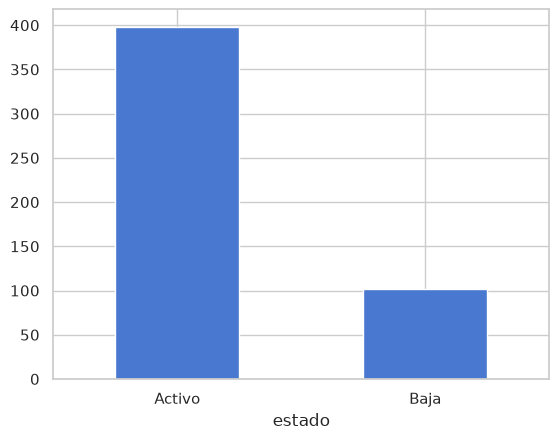

In [16]:
df['estado'].value_counts().plot.bar(rot=0)


<Axes: xlabel='segmento'>

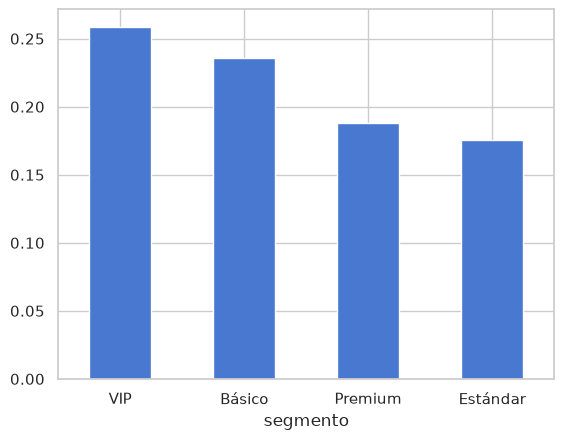

In [17]:
df.groupby('segmento')['churn'].mean().sort_values(ascending=False).plot.bar(rot=0)

<Axes: xlabel='plan_contratado'>

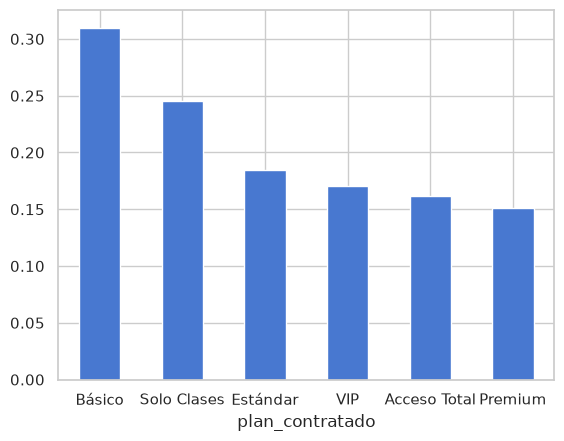

In [18]:
df.groupby('plan_contratado')['churn'].mean().sort_values(ascending=False).plot.bar(rot=0)


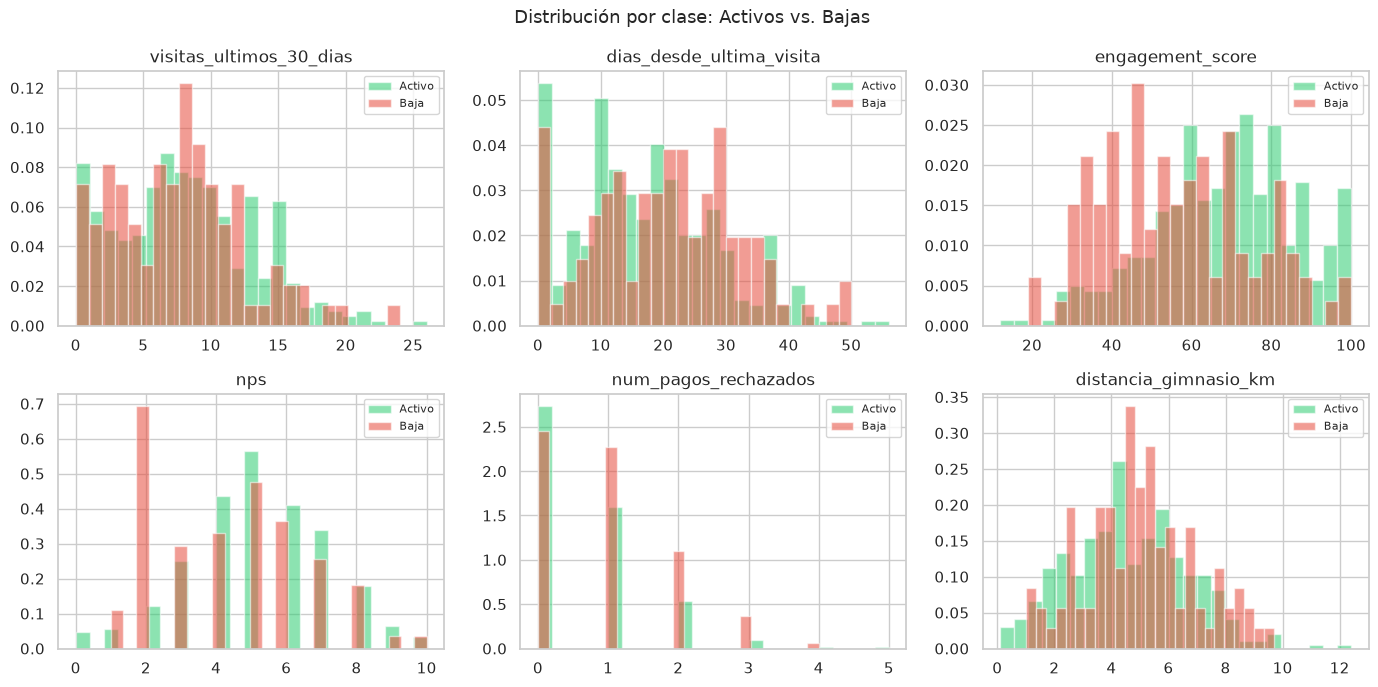

In [19]:
vars_num = [
    'visitas_ultimos_30_dias', 'dias_desde_ultima_visita',
    'engagement_score', 'nps', 'num_pagos_rechazados', 'distancia_gimnasio_km',
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, col in zip(axes, vars_num):
    for label, color, lbl in [(0,'#2ecc71','Activo'), (1,'#e74c3c','Baja')]:
        ax.hist(df[df['churn']==label][col].dropna(), bins=25,
                alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribución por clase: Activos vs. Bajas', fontsize=13)
plt.tight_layout()
plt.show()

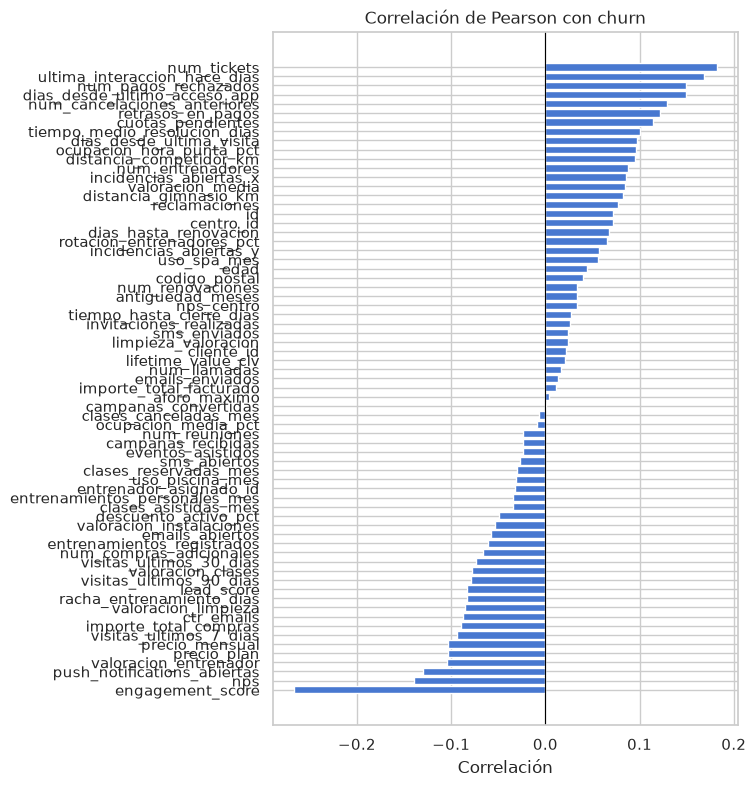

In [21]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr_churn = df[num_cols].corr()['churn'].drop('churn').sort_values()

fig, ax = plt.subplots(figsize=(6, 9))
ax.barh(corr_churn.index, corr_churn.values)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con churn')
ax.set_xlabel('Correlación')
plt.show()